# CR-lq-RMMGKS


# 📦 Imports and Utilities

In [1]:
from rmmgks import *
from cr_rmmgks import *
from helpers import *

## Test 1: Small scale CT

In [41]:
nx = 64
ny = nx
problem = generate_problem(phantom_name='tectonic', nx=nx
                           , ny=ny, t_end=1
                           , v_max=1, v_min=0, padding=3, root='',add =0,)
x_true = problem['u_traj'][0]

shape = problem['shape']
nx,ny = shape


views = 60

theta = np.linspace(0, 60, views, endpoint=False)
A = create_forward_op_ct(nx, ny, theta=theta,s=2)
b_true = A @ x_true.reshape(-1, 1) 

noise_level = 0.005
noise = np.random.randn(b_true.shape[0]).reshape((-1, 1))
e = noise_level * np.linalg.norm(b_true) / np.linalg.norm(noise) * noise
e = e.reshape((-1, 1))

b = b_true + e

delta = la.norm(e) 
L = gen_first_derivative_operator_2D(nx, ny)

Problem Description:
- Phantom: tectonic
- Image size: 64 x 64
- Number of frames: 1
- Output directory: /problem_64_by_64_tectonic_20260312_162712



C:\Users\okuno\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [42]:
def run_exp():
    all_results = {}
    for qnorm in [1,2]:
        for new_weights in [True,False]:
            print(f"Running with qnorm={qnorm} and new_weights={new_weights}")

            if new_weights is False:
                results = cr_rmmgks(A, b, x_true, L, nx, ny, delta,
                    N=1000, n_iter_first=600, n_iter_rest=400,
                    q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                    regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                    break_lambdah=False, break_x=True, break_check=0, break_tol=1e-14,
                    x_conv_tol=1e-16, d_limit=0,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape))
            else:
                results = cr_rmmgks(
                A, b, x_true, L, nx, ny, delta,
                N=1000, n_iter_first=200, n_iter_rest=400,
                q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                break_lambdah=False, break_x=True, break_check=0, break_tol=1e-4,
                x_conv_tol=1e-16, d_limit=0,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape)
                )
            all_results[(qnorm, new_weights)] = results
    return all_results
        


In [43]:
results = run_exp()

Running with qnorm=1 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 166.11it/s]


Outer Iteration 1/1000: RRE = 0.2406, Time = 6.22s
Stopping naturally: x stabilized at iteration 101
Outer Iteration 2/1000: RRE = 0.1762, Time = 3.30s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 3/1000: RRE = 0.1408, Time = 1.94s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 4/1000: RRE = 0.0836, Time = 2.02s
Stopping naturally: x stabilized at iteration 58
Outer Iteration 5/1000: RRE = 0.0478, Time = 2.07s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 6/1000: RRE = 0.0357, Time = 0.67s
Stopping naturally: x stabilized at iteration 20
Outer Iteration 7/1000: RRE = 0.0254, Time = 0.64s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 8/1000: RRE = 0.0194, Time = 0.61s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 9/1000: RRE = 0.0150, Time = 0.65s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 10/1000: RRE = 0.0114, Time = 0.66s
Stopping naturally: x stabilized at iteration 1

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 202.73it/s]


Outer Iteration 1/1000: RRE = 0.1724, Time = 19.51s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 19.51s
Running with qnorm=2 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 216.47it/s]


Stopping naturally: x stabilized at iteration 161
Outer Iteration 1/1000: RRE = 0.3424, Time = 5.05s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 2/1000: RRE = 0.3301, Time = 2.49s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 3/1000: RRE = 0.3146, Time = 2.08s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 4/1000: RRE = 0.3004, Time = 1.41s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 5/1000: RRE = 0.2885, Time = 1.40s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 6/1000: RRE = 0.2698, Time = 1.53s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 7/1000: RRE = 0.2394, Time = 1.43s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 8/1000: RRE = 0.2132, Time = 1.42s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 9/1000: RRE = 0.1836, Time = 1.47s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 10/1000: RRE = 0.1599, Time = 1.57

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 187.92it/s]


Outer Iteration 1/1000: RRE = 0.3156, Time = 23.84s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 23.84s


c:\Users\okuno\Desktop\cr-lq-rmmgks\helpers.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


✓ Saved: figure_snapshot.pdf


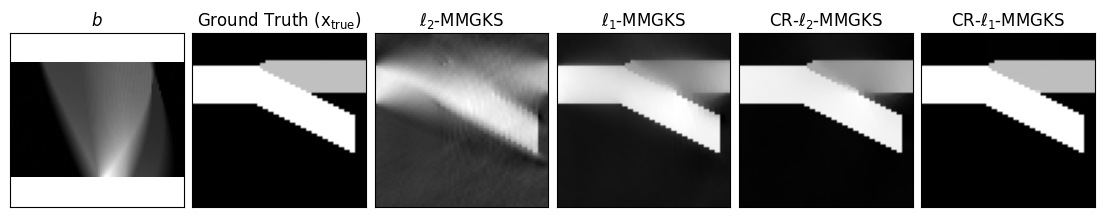

In [44]:
_ = plot_snapshot(results,x_true.reshape(nx,ny), b.reshape(len(theta),-1))

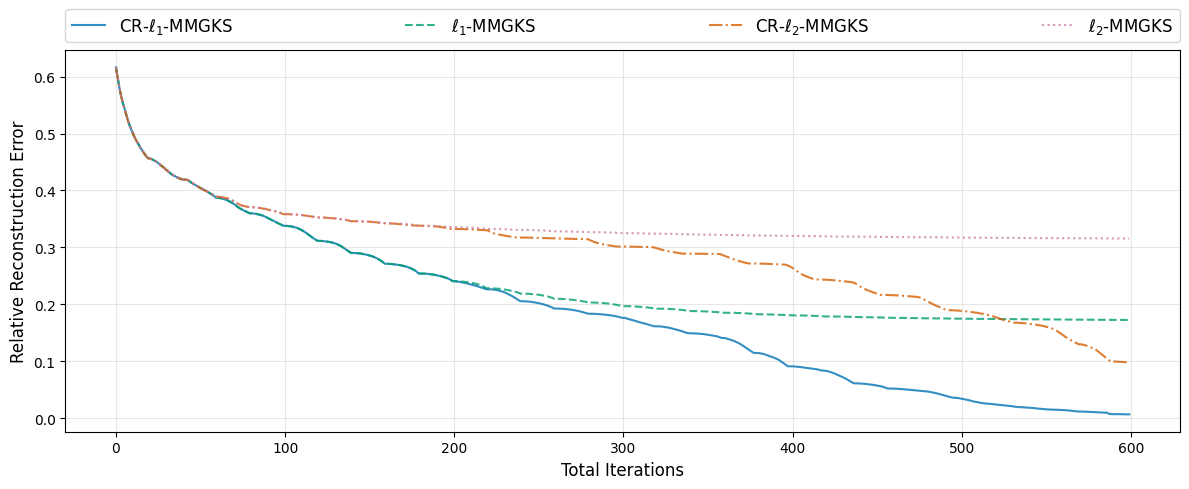

In [45]:
_ = plot_convergence(results,n=600)

## Test 2: 1D Signal Deblurring

In [23]:
from trips.test_problems.Deblurring1D import *
Deblur1D = Deblurring1D(CommitCrime = True)
nx = 200
ny = 1
import numpy as np
np.random.seed(9)
def piecewise_pulse_signal(nx, pulse_centers= [-5, -3,-1,1, 3,5][::] , pulse_widths= [2, 1.2, 1.6,1.6,1.8,1.2][::] , pulse_heights = [.1,.3,.5,.6,.3,.5][::]):
    t = np.linspace(-6, 6, nx)
    y = np.zeros_like(t)
    pulse_widths = np.array(pulse_widths)/2

    for c, w, h in zip(pulse_centers, pulse_widths, pulse_heights):
        y[(t >= c - w/2) & (t <= c + w/2)] = h

    return y
y = piecewise_pulse_signal(nx)
y = y/y.max()

x_true = y #Deblur1D.gen_xtrue(nx, test = 'piecewise')#
x_true/=x_true.max()
# If you would like to create the operator only
A = Deblur1D.forward_Op_1D(parameter =5  , nx = nx) 
# The following creates the data b_true
b_true = Deblur1D.gen_data(x_true)
(d, delta) = Deblur1D.add_noise(b_true, 'Gaussian', noise_level = 0.01)
b = d.reshape((-1,1))
# Display relevant quantities using the methods of the Deblurring1D class 
# Deblur1D.plot_rec(x_true)
# Deblur1D.plot_data(d)
L = gen_first_derivative_operator(nx)

C:\Users\okuno\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [35]:
def run_exp():
    all_results = {}
    for qnorm in [1,2]:
        for new_weights in [True,False]:
            print(f"Running with qnorm={qnorm} and new_weights={new_weights}")

            if new_weights is False:
                results = cr_rmmgks(A, b, x_true, L, nx, ny, delta,
                    N=1000, n_iter_first=600, n_iter_rest=400,
                    q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                    regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                    break_lambdah=False, break_x=True, break_check=0, break_tol=1e-14,
                    x_conv_tol=1e-16, d_limit=1e-3
                    ,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape))
            else:
                results = cr_rmmgks(
                A, b, x_true, L, nx, ny, delta,
                N=1000, n_iter_first=200, n_iter_rest=400,
                q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                break_lambdah=False, break_x=True, break_check=0, break_tol=1e-4,
                x_conv_tol=1e-16, d_limit=1e-3,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape)
                )
            all_results[(qnorm, new_weights)] = results
    return all_results
        


In [36]:
results = run_exp()

Running with qnorm=1 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 2200.58it/s]


Stopping naturally: x stabilized at iteration 160
Outer Iteration 1/1000: RRE = 0.1592, Time = 0.40s
Stopping naturally: x stabilized at iteration 55
Outer Iteration 2/1000: RRE = 0.0419, Time = 0.13s
Stopping naturally: x stabilized at iteration 21
Outer Iteration 3/1000: RRE = 0.0333, Time = 0.05s
Stopping naturally: x stabilized at iteration 13
Outer Iteration 4/1000: RRE = 0.0287, Time = 0.03s
Stopping naturally: x stabilized at iteration 8
Outer Iteration 5/1000: RRE = 0.0253, Time = 0.03s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 6/1000: RRE = 0.0141, Time = 0.04s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 7/1000: RRE = 0.0053, Time = 0.04s
Stopping naturally: x stabilized at iteration 8
Outer Iteration 8/1000: RRE = 0.0049, Time = 0.03s
Stopping naturally: x stabilized at iteration 3
Outer Iteration 9/1000: RRE = 0.0048, Time = 0.01s
Stopping naturally: x stabilized at iteration 3
Outer Iteration 10/1000: RRE = 0.0047, Time = 0.01s
St

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 2484.48it/s]


Outer Iteration 1/1000: RRE = 0.1040, Time = 1.44s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 1.44s
Running with qnorm=2 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 1671.30it/s]

Stopping naturally: x stabilized at iteration 42
Outer Iteration 1/1000: RRE = 0.3038, Time = 0.10s


Stopping naturally: x stabilized at iteration 99
Outer Iteration 2/1000: RRE = 0.2213, Time = 0.26s
Stopping naturally: x stabilized at iteration 38
Outer Iteration 3/1000: RRE = 0.1764, Time = 0.09s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 4/1000: RRE = 0.1119, Time = 0.17s
Stopping naturally: x stabilized at iteration 98
Outer Iteration 5/1000: RRE = 0.0495, Time = 0.21s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 6/1000: RRE = 0.0380, Time = 0.09s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 7/1000: RRE = 0.0365, Time = 0.05s
Stopping naturally: x stabilized at iteration 4
Outer Iteration 8/1000: RRE = 0.0365, Time = 0.01s
Stopping naturally: x stabilized at iteration 3
Outer Iteration 9/1000: RRE = 0.0364, Time = 0.01s
Stopping naturally: x stabilized at iteration 3
Outer Iteration 10/1000: RRE = 0.0364, Time = 0.01s
Stopping naturally: x stabilized at iteration 3
Outer Iteration 11/1000: RRE = 0.0363, Time = 0.01s
St

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 1420.35it/s]


Outer Iteration 1/1000: RRE = 0.3050, Time = 0.98s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 0.98s


c:\Users\okuno\Desktop\cr-lq-rmmgks\helpers.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


✓ Saved: figure_snapshot.pdf


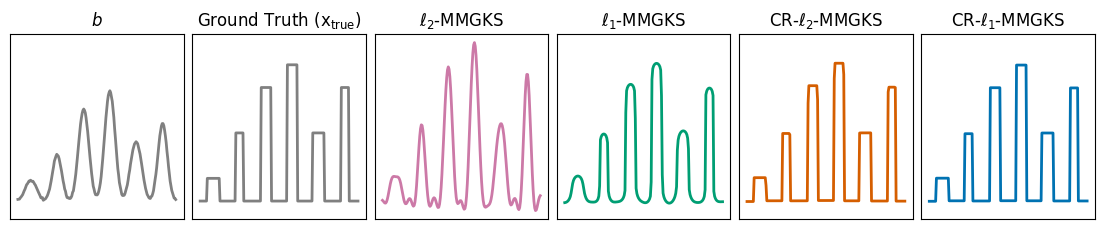

In [38]:
_ = plot_snapshot(results,x_true.reshape(nx,ny),b)

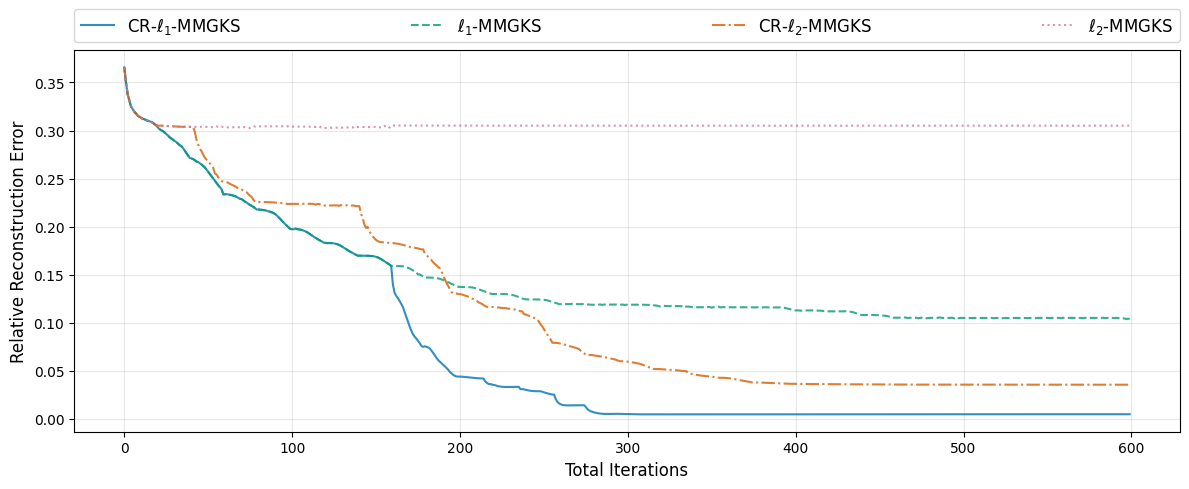

In [40]:
_ = plot_convergence(results,n=600)

## Test 3: 2D Deblurring

In [69]:


from trips.test_problems.Deblurring2D import *
Deblur2D = Deblurring2D(CommitCrime = True)
nx = 64
ny = nx
problem = generate_problem(phantom_name='grains', nx=nx
                           , ny=None, t_end=1
                           , v_max=1, v_min=0, padding=3, root='exp/exp1',add =0,)
u_traj = problem['u_traj']

shape = problem['shape']
nx,ny = shape
x_true = u_traj[0]#
# nx,ny = 128,128
x_true = Deblur2D.gen_true(im= 'satellite',nx=nx, ny = ny )#
# If you would like to create te operator only
A = Deblur2D.forward_Op(dim = (3,3), spread = (2,2), nx = nx, ny = ny) #create_forward_op_blur(nx=nx, ny=ny, dim=[3]*2, spread=2) #
# The following creates the data b_true
#b_true = A@ x_true#Deblur2D.gen_data(x_true)
b_true = A @ x_true.reshape(-1, 1) 

noise_level = 0.001
noise = np.random.randn(b_true.shape[0]).reshape((-1, 1))
e = noise_level * np.linalg.norm(b_true) / np.linalg.norm(noise) * noise
e = e.reshape((-1, 1))

b = b_true + e

delta = la.norm(e) 
L = gen_first_derivative_operator_2D(nx, ny)
#(d, delta) = Deblur2D.add_noise(b_true, 'Gaussian', noise_level = 0.01)
#b = d.reshape((-1,1))
# Display relevant quantities using the methods of the Deblurring1D class 
# Deblur1D.plot_rec(X_true_bar)
# Deblur1D.plot_data(d)
#L = gen_first_derivative_operator_2D(nx,ny)

Problem Description:
- Phantom: grains
- Image size: 64 x 64
- Number of frames: 1
- Output directory: exp/exp1/problem_64_by_64_grains_20260312_163454

data already in the path.


In [70]:
def run_exp():
    all_results = {}
    for qnorm in [1,2]:
        for new_weights in [True,False]:
            print(f"Running with qnorm={qnorm} and new_weights={new_weights}")

            if new_weights is False:
                results = cr_rmmgks(A, b, x_true, L, nx, ny, delta,
                    N=1000, n_iter_first=600, n_iter_rest=400,
                    q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                    regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                    break_lambdah=False, break_x=True, break_check=0, break_tol=1e-14,
                    x_conv_tol=1e-16, d_limit=1e-3
                    ,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape))
            else:
                results = cr_rmmgks(
                A, b, x_true, L, nx, ny, delta,
                N=1000, n_iter_first=200, n_iter_rest=400,
                q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                break_lambdah=False, break_x=True, break_check=0, break_tol=1e-4,
                x_conv_tol=1e-16, d_limit=1e-3,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape)
                )
            all_results[(qnorm, new_weights)] = results
    return all_results
        


In [71]:
results = run_exp()

Running with qnorm=1 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 560.15it/s]


Stopping naturally: x stabilized at iteration 181
Outer Iteration 1/1000: RRE = 0.0426, Time = 3.94s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 2/1000: RRE = 0.0362, Time = 0.54s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 3/1000: RRE = 0.0311, Time = 0.56s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 4/1000: RRE = 0.0267, Time = 0.55s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 5/1000: RRE = 0.0240, Time = 0.55s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 6/1000: RRE = 0.0224, Time = 0.56s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 7/1000: RRE = 0.0210, Time = 0.61s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 8/1000: RRE = 0.0203, Time = 0.59s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 9/1000: RRE = 0.0191, Time = 0.57s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 10/1000: RRE = 0.0183, Time = 0.57

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 474.14it/s]


Outer Iteration 1/1000: RRE = 0.0327, Time = 18.59s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 18.60s
Running with qnorm=2 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 491.03it/s]


Stopping naturally: x stabilized at iteration 120
Outer Iteration 1/1000: RRE = 0.0970, Time = 2.31s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 2/1000: RRE = 0.0854, Time = 1.37s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 3/1000: RRE = 0.0586, Time = 1.56s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 4/1000: RRE = 0.0403, Time = 1.47s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 5/1000: RRE = 0.0328, Time = 1.95s
Stopping naturally: x stabilized at iteration 20
Outer Iteration 6/1000: RRE = 0.0284, Time = 0.97s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 7/1000: RRE = 0.0244, Time = 0.86s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 8/1000: RRE = 0.0220, Time = 0.79s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 9/1000: RRE = 0.0197, Time = 0.84s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 10/1000: RRE = 0.0183, Time = 0.83

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 331.68it/s]


Outer Iteration 1/1000: RRE = 0.0900, Time = 13.22s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 13.22s


c:\Users\okuno\Desktop\cr-lq-rmmgks\helpers.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


✓ Saved: figure_snapshot.pdf


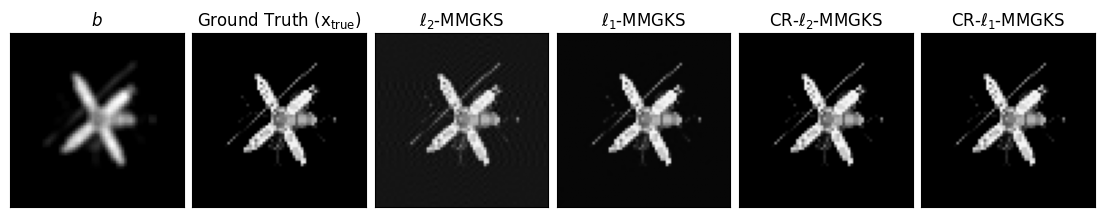

In [72]:
_ = plot_snapshot(results,x_true.reshape(nx,ny),b.reshape(nx,ny))

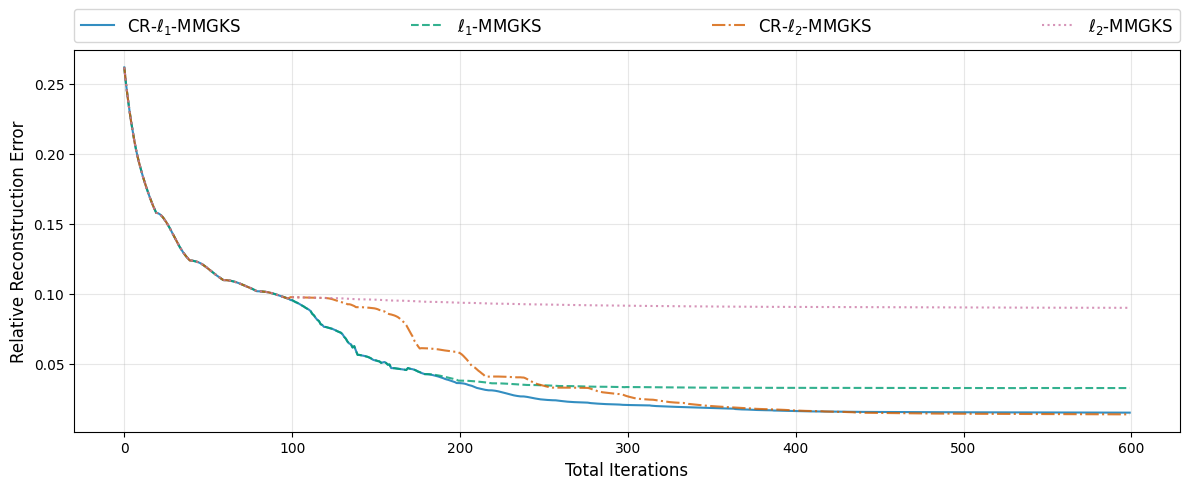

In [73]:
_ = plot_convergence(results,n=600)

## Test 4: Large Scale CT

In [74]:
nx = 128
ny = nx
problem = generate_problem(phantom_name='shepp_logan', nx=nx
                           , ny=ny, t_end=1
                           , v_max=1, v_min=0, padding=3, root='',add =0,)
x_true = problem['u_traj'][0]

shape = problem['shape']
nx,ny = shape


views = 30

theta = np.linspace(0, 180, views, endpoint=False)
A = create_forward_op_ct(nx, ny, theta=theta,s=2)
b_true = A @ x_true.reshape(-1, 1) 

noise_level = 0.01
noise = np.random.randn(b_true.shape[0]).reshape((-1, 1))
e = noise_level * np.linalg.norm(b_true) / np.linalg.norm(noise) * noise
e = e.reshape((-1, 1))

b = b_true + e

delta = la.norm(e) 
L = gen_first_derivative_operator_2D(nx, ny)

Problem Description:
- Phantom: shepp_logan
- Image size: 128 x 128
- Number of frames: 1
- Output directory: /problem_128_by_128_shepp_logan_20260312_163733



C:\Users\okuno\AppData\Roaming\Python\Python312\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [75]:
def run_exp():
    all_results = {}
    for qnorm in [1,2]:
        for new_weights in [True,False]:
            print(f"Running with qnorm={qnorm} and new_weights={new_weights}")

            if new_weights is False:
                results = cr_rmmgks(A, b, x_true, L, nx, ny, delta,
                    N=1000, n_iter_first=600, n_iter_rest=400,
                    q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                    regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                    break_lambdah=False, break_x=True, break_check=0, break_tol=1e-14,
                    x_conv_tol=1e-16, d_limit=0,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape))
            else:
                results = cr_rmmgks(
                A, b, x_true, L, nx, ny, delta,
                N=1000, n_iter_first=200, n_iter_rest=400,
                q=2.0, pnorm=2, qnorm=qnorm, kmin=5, kmax=25,
                regparam='dp', non_neg=False,epsilon=1e-2, tolambdah=1e-6, 
                break_lambdah=False, break_x=True, break_check=0, break_tol=1e-4,
                x_conv_tol=1e-16, d_limit=0,use_non_neg=False, new_weights=new_weights, adaptive_epsilon=False, max_total_iters=600,x0 = np.ones((A.T@b).shape)
                )
            all_results[(qnorm, new_weights)] = results
    return all_results
        


In [76]:
results = run_exp()

Running with qnorm=1 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...:   0%|          | 0/5 [00:00<?, ?it/s]

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 88.69it/s]


Stopping naturally: x stabilized at iteration 80
Outer Iteration 1/1000: RRE = 0.1558, Time = 5.88s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 2/1000: RRE = 0.1434, Time = 2.79s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 3/1000: RRE = 0.1296, Time = 2.67s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 4/1000: RRE = 0.1151, Time = 2.56s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 5/1000: RRE = 0.1025, Time = 2.72s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 6/1000: RRE = 0.0971, Time = 1.26s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 7/1000: RRE = 0.0947, Time = 1.33s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 8/1000: RRE = 0.0939, Time = 1.38s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 9/1000: RRE = 0.0935, Time = 1.31s
Stopping naturally: x stabilized at iteration 15
Outer Iteration 10/1000: RRE = 0.0930, Time = 1.12s

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 80.25it/s]


Outer Iteration 1/1000: RRE = 0.1535, Time = 45.31s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 45.31s
Running with qnorm=2 and new_weights=True
--- Starting Iterative Reconstruction ---


generating basis...: 100%|██████████| 5/5 [00:00<00:00, 86.62it/s]


Stopping naturally: x stabilized at iteration 60
Outer Iteration 1/1000: RRE = 0.3904, Time = 4.33s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 2/1000: RRE = 0.3416, Time = 2.94s
Stopping naturally: x stabilized at iteration 59
Outer Iteration 3/1000: RRE = 0.2833, Time = 4.52s
Stopping naturally: x stabilized at iteration 39
Outer Iteration 4/1000: RRE = 0.2443, Time = 3.09s
Stopping naturally: x stabilized at iteration 38
Outer Iteration 5/1000: RRE = 0.2105, Time = 2.86s
Stopping naturally: x stabilized at iteration 21
Outer Iteration 6/1000: RRE = 0.1941, Time = 1.81s
Stopping naturally: x stabilized at iteration 21
Outer Iteration 7/1000: RRE = 0.1741, Time = 1.62s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 8/1000: RRE = 0.1572, Time = 1.54s
Stopping naturally: x stabilized at iteration 19
Outer Iteration 9/1000: RRE = 0.1433, Time = 1.55s
Stopping naturally: x stabilized at iteration 18
Outer Iteration 10/1000: RRE = 0.1352, Time = 1.41s

generating basis...: 100%|██████████| 5/5 [00:00<00:00, 81.67it/s]


Outer Iteration 1/1000: RRE = 0.3898, Time = 45.81s

Reached maximum total iterations (600). Stopping.

--- Reconstruction Finished ---
Total Outer Iterations: 1
Total Inner Iterations: 600
Total Execution Time: 45.82s


c:\Users\okuno\Desktop\cr-lq-rmmgks\helpers.py:870: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


✓ Saved: figure_snapshot.pdf


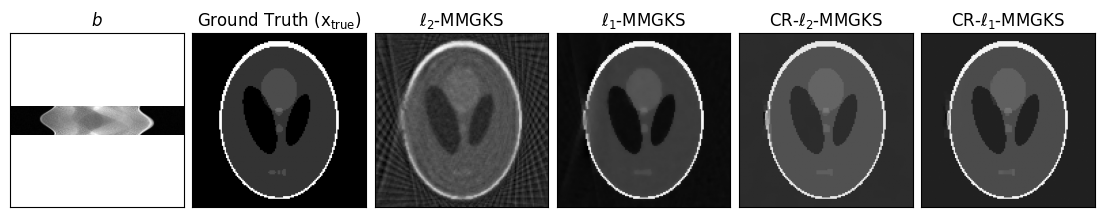

In [77]:
_ = plot_snapshot(results,x_true.reshape(nx,ny), b.reshape(len(theta),-1))

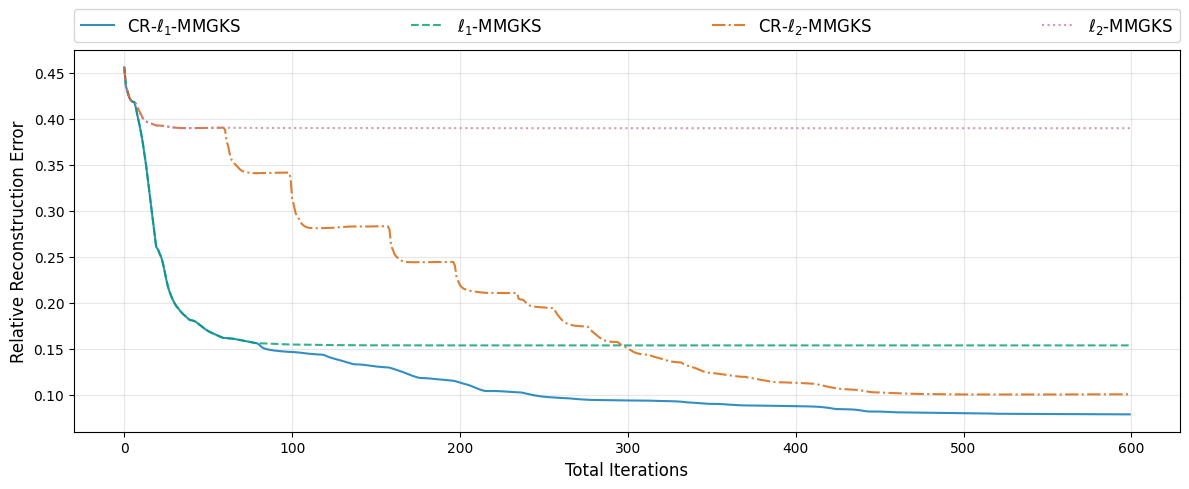

In [78]:
_ = plot_convergence(results,n=600)